## Importing and celaning data


In [1]:
import pandas as pd
import duckdb

pd.set_option("display.max_columns", None)  # show all cols
pd.set_option("display.max_colwidth", None)  # show full width of showing cols
pd.set_option(
    "display.expand_frame_repr", False
)  # print cols side by side as it's supposed to be


ODIS_DUCKDB_FILE = "odis.duckdb"
PCC_DUCKDB_FILE = "dev.duckdb"

con = duckdb.connect(database=PCC_DUCKDB_FILE, read_only=True)
con.sql(f"ATTACH '{ODIS_DUCKDB_FILE}' AS odis;")


In [2]:
query_catnat = """
SELECT *
  FROM dev.main.catnat_gaspar
  ORDER BY cod_commune ASC;
"""

cat_nat_2000 = con.sql(query_catnat)
cat_nat_2000_df = cat_nat_2000.df()

query_odis3 = """SELECT * FROM odis.gold_gold_typologies_territoires
ORDER BY codgeo ASC;"""
odis_topology = con.sql(query_odis3).df()


In [3]:
con = duckdb.connect()

query = open(
    r"C:\\Users\\marin\\OneDrive\Documentos\\GitHub\\14_PrixChangementClimatique\\data\\dbt_pipeline\\models\bronze\\primes_assurances_communes.sql"
).read()

assurance_df = con.execute(query).fetchdf()

print(assurance_df.head())

   annee           siret code_departement  code_insee  code_region  compte  solde_debiteur  solde_crediteur code_geo
0   2021  21170035600010              017          35           75    6161         1618.92              0.0    01735
1   2021  21020032500012              002          32           32    6168          866.22              0.0    00232
2   2021  21550504100016              055         504           44    6161         5138.16              0.0   055504
3   2021  21570058400208              057          58           44    6161        46737.03              0.0    05758
4   2021  21860182100018              086         182           75    6168          694.00              0.0   086182


In [4]:
# informacion de comunas y riesgos
data_chomage = pd.read_csv(
    r"C:\Users\marin\OneDrive\Documentos\GitHub\14_PrixChangementClimatique\data\dbt_pipeline\pipeline_inputs\taux_chomage_communes.csv"
)

In [5]:
from datetime import datetime

climate_data = pd.DataFrame(
    {
        "lib_commune": cat_nat_2000_df["lib_commune"],
        "cod_commune": cat_nat_2000_df["cod_commune"],
        "climate_risk": cat_nat_2000_df["lib_risque_jo"],
        "durée événement": pd.to_datetime(cat_nat_2000_df["dat_fin"], format="mixed")
        - pd.to_datetime(cat_nat_2000_df["dat_deb"], format="mixed"),
        "cat_nat_recognition": cat_nat_2000_df["dat_pub_jo"],
        "recognition_time": pd.to_datetime(
            cat_nat_2000_df["dat_pub_jo"], format="mixed"
        )
        - pd.to_datetime(cat_nat_2000_df["dat_fin"], format="mixed"),
    }
)
climate_df = (
    climate_data.groupby(["cod_commune", "lib_commune", "climate_risk"])
    .agg(
        duree_event_mean=("durée événement", "mean"),
        duree_event_max=("durée événement", "max"),
        nb_events=("durée événement", "count"),
        time_recognition_mean=("recognition_time", "mean"),
        time_recognition_max=("recognition_time", "max"),
    )
    .reset_index()
)

In [6]:
data_chomage.head(1)  # donnes T3_2025_proxy_commune codgeo

,code_region,region,code_departement,departement,code_commune,commune,codgeo,nombre_de_demandeurs_d_emploi,p23_pop,ratio_ABC_pop_commune,ratio_ABC_pop_dep,T3_2025_departement,T3_2025_proxy_commune
0,84,Auvergne-Rhône-Alpes,01,Ain,01006,Ambléon,01006,10,115.0,0.086957,0.065644,5.7,7.55


In [7]:
climate_data.head(1)  # durée événement	recognition_time climate_risk cod_commune

,lib_commune,cod_commune,climate_risk,durée événement,cat_nat_recognition,recognition_time
0,L'Abergement-Clémenciat,01001,Inondations et/ou Coulées de Boue,0 days,1984-10-18,119 days


In [8]:
assurance_df.head(1)  # code_geo solde_debiteur solde_crediteur

,annee,siret,code_departement,code_insee,code_region,compte,solde_debiteur,solde_crediteur,code_geo
0,2021,21170035600010,017,35,75,6161,1618.92,0.0,01735


## Visualisations et analyses


In [9]:
import matplotlib.pyplot as plt

### 1) Il y a une relation entre le temps jusqu'à la reconaissance d'un fenomène climatiques et le taux de chômage dans les comunes?


In [10]:
# Organiser les données pour la visualisation
climated_df_grouped = (
    climate_data.groupby(["cod_commune", "climate_risk"])["recognition_time"]
    .sum()
    .reset_index()
)
climated_df_grouped.head()

,cod_commune,climate_risk,recognition_time
0,01001,Inondations et/ou Coulées de Boue,222 days
1,01002,Inondations et/ou Coulées de Boue,187 days
2,01004,Inondations et/ou Coulées de Boue,284 days
3,01004,Mouvement de Terrain,103 days
4,01004,Sécheresse,1566 days


In [11]:
# by far, the events that takes more time to eb recongnized are Séchresse and Mouvement de terrain. So I will analyse them
climated_df_grouped.groupby("climate_risk")["recognition_time"].max()

climate_risk
Avalanche                                      1316 days
Chocs Mécaniques liés à l'action des Vagues    3067 days
Coulée de Boue                                 1278 days
Divers                                          166 days
Eboulement et/ou Chute de Blocs                 972 days
Effondrement et/ou Affaisement                 2112 days
Eruption Volcanique                             585 days
Glissement de Terrain                          3790 days
Glissement et Eboulement Rocheux                267 days
Glissement et Effondrement de Terrain           284 days
Grêle                                          1200 days
Inondations Remontée Nappe                     3687 days
Inondations et/ou Coulées de Boue              9674 days
Lave Torrentielle                               414 days
Mouvement de Terrain                          26610 days
Poids de la Neige                               729 days
Raz de Marée                                    277 days
Secousse Sismique 

In [12]:
# I will analyse the relation between the time of recognition of Sécheresse and the taux de chomage
sech_data = climated_df_grouped[
    climated_df_grouped["climate_risk"].isin(["Sécheresse"])
]
merged_data = pd.merge(
    data_chomage, sech_data, left_on="codgeo", right_on="cod_commune", how="inner"
)
merged_data.head(1)

,code_region,region,code_departement,departement,code_commune,commune,codgeo,nombre_de_demandeurs_d_emploi,p23_pop,ratio_ABC_pop_commune,ratio_ABC_pop_dep,T3_2025_departement,T3_2025_proxy_commune,cod_commune,climate_risk,recognition_time
0,84,Auvergne-Rhône-Alpes,01,Ain,01012,Aranc,01012,20,331.0,0.060423,0.065644,5.7,5.25,01012,Sécheresse,660 days


                       recognition_time  T3_2025_proxy_commune
recognition_time               1.000000              -0.036292
T3_2025_proxy_commune         -0.036292               1.000000


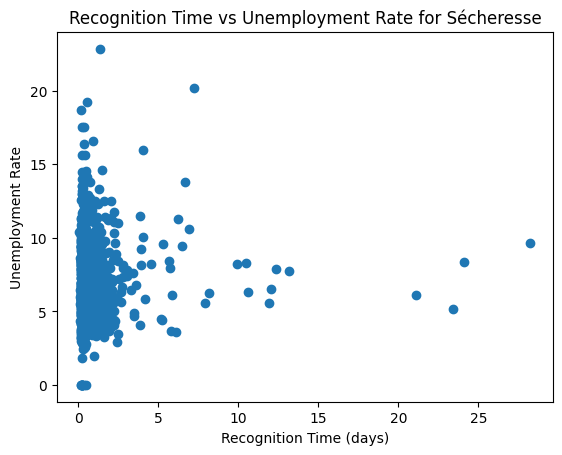

In [13]:
# visualisation of the relation between the time of recognition of Sécheresse and the taux de chomage

plt.scatter(
    merged_data["recognition_time"] / merged_data["recognition_time"].mean(),
    merged_data["T3_2025_proxy_commune"],
)
plt.xlabel("Recognition Time (days)")
plt.ylabel("Unemployment Rate")
plt.title("Recognition Time vs Unemployment Rate for Sécheresse")

# Calculate Spearman correlation
corr1 = merged_data[["recognition_time", "T3_2025_proxy_commune"]].corr(
    method="spearman"
)
print(corr1)


In [14]:
# I will do a linear regression to see if there is a relation between the time of recognition of Sécheresse and the taux de chomage

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


X = merged_data[["T3_2025_proxy_commune"]]
y = merged_data["recognition_time"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print("R^2:", r2)
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

R^2: 0.0006989863121664719
MSE: 3.4971393356430305e+28


In [32]:
# I will analyse the relation between the time of recognition of Mouvement de Terrain and the taux de chomage
mouv_data = climated_df_grouped[
    climated_df_grouped["climate_risk"].isin(["Mouvement de Terrain"])
]
merged_data2 = pd.merge(
    data_chomage, mouv_data, left_on="codgeo", right_on="cod_commune", how="inner"
)
merged_data2.head(1)

,code_region,region,code_departement,departement,code_commune,commune,codgeo,nombre_de_demandeurs_d_emploi,p23_pop,ratio_ABC_pop_commune,ratio_ABC_pop_dep,T3_2025_departement,T3_2025_proxy_commune,cod_commune,climate_risk,recognition_time
0,84,Auvergne-Rhône-Alpes,01,Ain,01021,Ars-sur-Formans,01021,75,1528.0,0.049084,0.065644,5.7,4.26,01021,Mouvement de Terrain,103 days


                       recognition_time  T3_2025_proxy_commune
recognition_time               1.000000               0.041931
T3_2025_proxy_commune          0.041931               1.000000


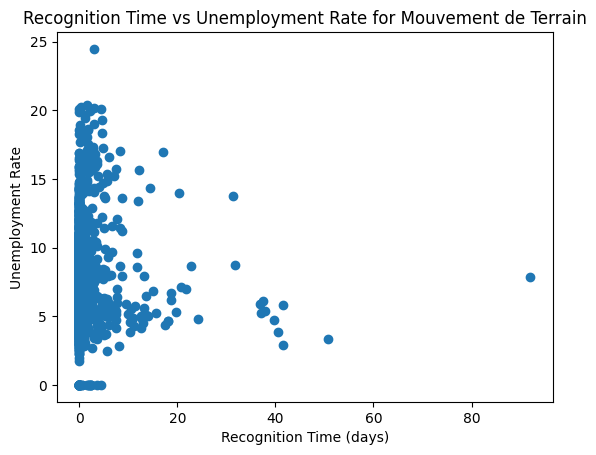

In [33]:
# visualisation of the relation between the time of recognition of Sécheresse and the taux de chomage

plt.scatter(
    merged_data2["recognition_time"] / merged_data2["recognition_time"].mean(),
    merged_data2["T3_2025_proxy_commune"],
)
plt.xlabel("Recognition Time (days)")
plt.ylabel("Unemployment Rate")
plt.title("Recognition Time vs Unemployment Rate for Mouvement de Terrain")

# Calculate Spearman correlation
corr2 = merged_data2[["recognition_time", "T3_2025_proxy_commune"]].corr(
    method="spearman"
)
print(corr2)


In [34]:
X = merged_data2[["T3_2025_proxy_commune"]]
y = merged_data2["recognition_time"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r22 = r2_score(y, y_pred)
print("R^2:", r22)
mse2 = mean_squared_error(y, y_pred)
print("MSE:", mse2)

R^2: 4.240006371492022e-05
MSE: 1.8110794136202093e+27


##### I could go on trying with other types of events, but I will stop here for now. These results aling with the results other collegues had regarding cat_nat and demandeur d'emploi,so I think the same logic is evidenced here. The recognition of climate events does not change on the unemployement rate, it depends on other factors such as the type of event, the location, the political will, etc.


### 2) Il y a une relation entre le l'argent que les communes dépensent en assurance et le taux de chômage dans les comunes?


In [36]:
# preparation of the data for the analysis of the relation between the net depenses d'assurance and the taux de chomage.
# I will filter the coptes 6161 and 6168 that are the ones connected to climate assurance

assurance_df["Net_dep_assurance"] = (
    assurance_df["solde_debiteur"] - assurance_df["solde_crediteur"]
)
assurance_df_rc = assurance_df[assurance_df["compte"].isin([6161, 6168])]

assurance_commune = (
    assurance_df_rc.groupby(["code_geo", "annee"])
    .agg(
        {
            "Net_dep_assurance": sum,
        }
    )
    .reset_index()
)


In [39]:
merged_data2 = pd.merge(
    data_chomage, assurance_commune, left_on="codgeo", right_on="code_geo", how="inner"
)
merged_data2.head(1)

,code_region,region,code_departement,departement,code_commune,commune,codgeo,nombre_de_demandeurs_d_emploi,p23_pop,ratio_ABC_pop_commune,ratio_ABC_pop_dep,T3_2025_departement,T3_2025_proxy_commune,code_geo,annee,Net_dep_assurance
0,84,Auvergne-Rhône-Alpes,01,Ain,01011,Apremont,01011,25,415.0,0.060241,0.065644,5.7,5.23,01011,2017,3469.81


                       Net_dep_assurance  T3_2025_proxy_commune
Net_dep_assurance               1.000000              -0.019428
T3_2025_proxy_commune          -0.019428               1.000000


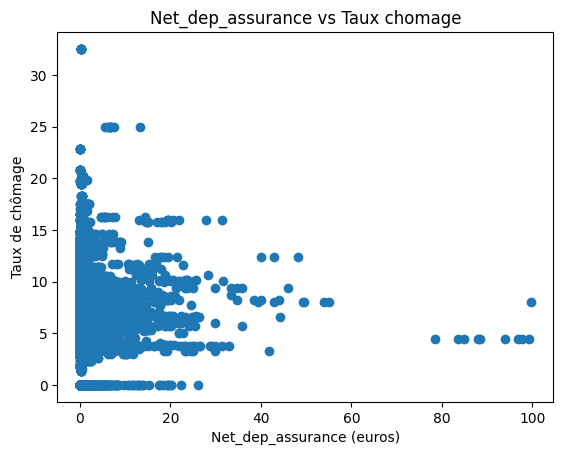

In [40]:
# first, I will visualise the relation between the net depenses d'assurance and the taux de chomage

plt.scatter(
    merged_data2["Net_dep_assurance"] / merged_data2["Net_dep_assurance"].mean(),
    merged_data2["T3_2025_proxy_commune"],
)
plt.xlabel("Net_dep_assurance (euros)")
plt.ylabel("Taux de chômage")
plt.title("Net_dep_assurance vs Taux chomage")


# I appply a corelation to see if there is a relation between the net depenses d'assurance and the taux de chomage

corr1 = merged_data2[["Net_dep_assurance", "T3_2025_proxy_commune"]].corr(
    method="spearman"
)
print(corr1)

                       Net_dep_assurance  T3_2025_proxy_commune
Net_dep_assurance               1.000000              -0.018652
T3_2025_proxy_commune          -0.018652               1.000000


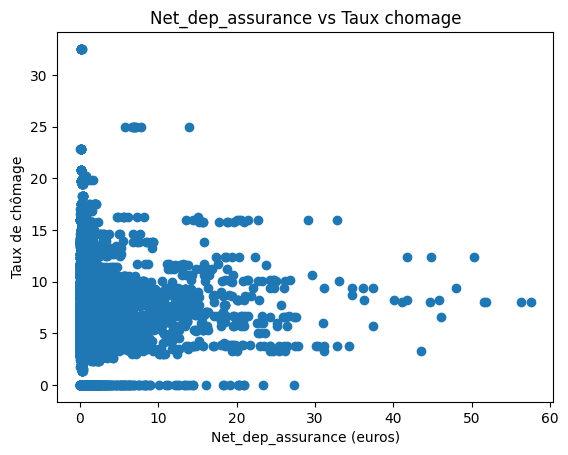

In [ ]:
# As I no see a relation between the net depenses d'assurance and the taux de chomage,
# I will try to see if there is a relation between the net depenses d'assurance and
# the taux de chomage for the communes that have a net depense d'assurance in the range of 60 euros (to avoid outliers).

filtered_data = merged_data2[
    merged_data2["Net_dep_assurance"] / merged_data2["Net_dep_assurance"].mean() <= 60
]
plt.scatter(
    filtered_data["Net_dep_assurance"] / filtered_data["Net_dep_assurance"].mean(),
    filtered_data["T3_2025_proxy_commune"],
)
plt.xlabel("Net_dep_assurance (euros)")
plt.ylabel("Taux de chômage")
plt.title("Net_dep_assurance vs Taux chomage")


corr1 = filtered_data[["Net_dep_assurance", "T3_2025_proxy_commune"]].corr(
    method="spearman"
)
print(corr1)

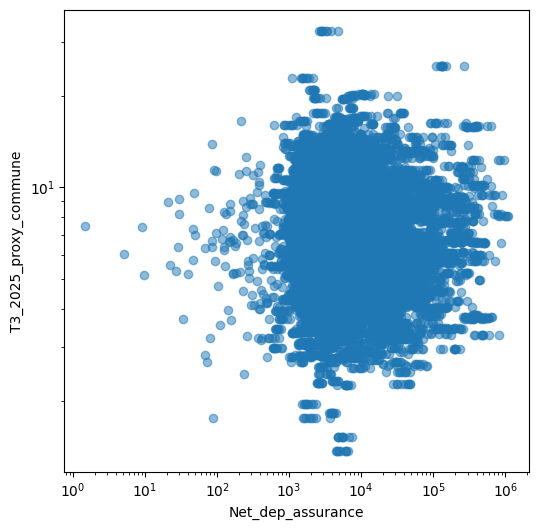

In [ ]:
# as I still don't see a relation, I will try to visualise the relation between the net depenses d'assurance
# and the taux de chomage in a log scale to see if there is a relation between the two variables.

plt.figure(figsize=(6, 6))
plt.scatter(
    filtered_data["Net_dep_assurance"],
    filtered_data["T3_2025_proxy_commune"],
    alpha=0.5,
)
plt.xlabel("Net_dep_assurance")
plt.ylabel("T3_2025_proxy_commune")
plt.xscale("log")
plt.yscale("log")
plt.show()

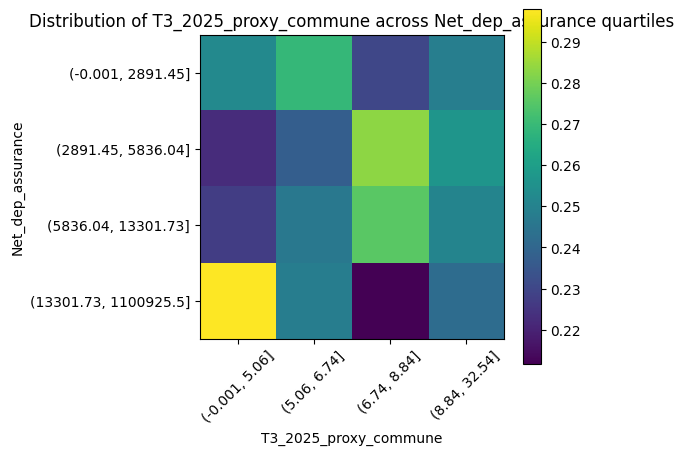

In [ ]:
# A I still don't see a relation, I will divide teh sample in intervals to is if  this way I can see a relation

import numpy as np

filtered_data["grupo_x"] = pd.qcut(filtered_data["Net_dep_assurance"], 4)
filtered_data["grupo_y"] = pd.qcut(filtered_data["T3_2025_proxy_commune"], 4)


cross = pd.crosstab(
    filtered_data["grupo_x"], filtered_data["grupo_y"], normalize="index"
)


plt.figure(figsize=(6, 5))

plt.imshow(cross.values)
plt.xticks(np.arange(len(cross.columns)), cross.columns, rotation=45)
plt.yticks(np.arange(len(cross.index)), cross.index)

plt.xlabel("T3_2025_proxy_commune")
plt.ylabel("Net_dep_assurance")
plt.title("Distribution of T3_2025_proxy_commune across Net_dep_assurance quartiles")
plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
# At last, I will apply a regression to see if there is a relation between the net depenses d'assurance and the taux de chomage

X = merged_data2[["T3_2025_proxy_commune"]]
y = merged_data2["Net_dep_assurance"]


model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

r2 = r2_score(y, y_pred)
print("R^2:", r2)
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

R^2: 4.2687202294611204e-05
MSE: 4488242834.997009


##### Il ne semble pas y avoir de corrélation forte entre le taux de chômage et les dépenses d’assurance.Les visualisations ne montrent pas de tendance générale claire, et les coefficients de corrélation confirment cette faible relation linéaire.La seule observation possible à ce stade est que certaines communes avec des taux de chômage plus faibles présentent des dépenses d’assurance plus élevées. Toutefois, ce résultat reste cohérent avec des facteurs socio-économiques attendus (niveau de revenu plus élevé, plus grande couverture assurantielle, patrimoine plus important, etc.).


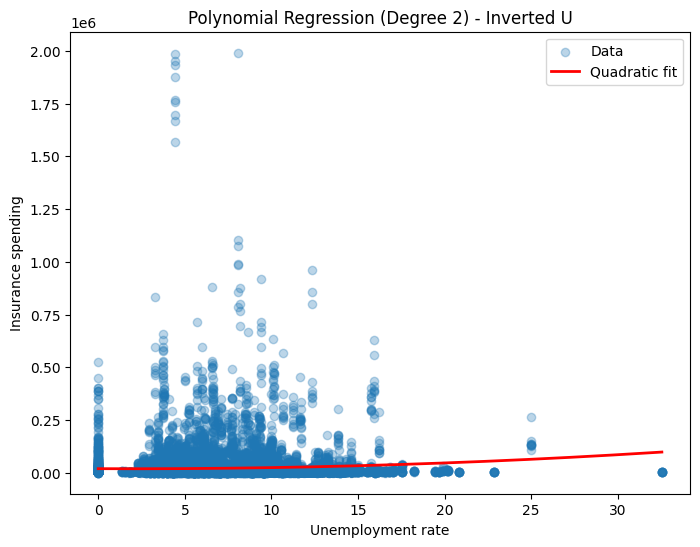

Intercept: 19147.230569531643
Coefficients: [   0.         -340.52991197   84.92791464]
This is a U-shape (convex).
Intercept: 19147.230569531643
Coefficients: [   0.         -340.52991197   84.92791464]
Quadratic coefficient (a): 84.9279146366913
Curve is U-shaped, consider multiplying y by -1 or using log transform if needed.


In [66]:
from sklearn.preprocessing import PolynomialFeatures

X = merged_data2[["T3_2025_proxy_commune"]].values
y = merged_data2["Net_dep_assurance"].values

# Polynomial features of degree 2
X_centered = X - X.mean()
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X_centered)

# Fit model
model = LinearRegression()
model.fit(X_poly, y)

# Predict
X_range = np.linspace(X.min(), X.max(), 500).reshape(-1, 1)
X_range_poly = poly.transform(X_range)
y_pred = model.predict(X_range_poly)


# Plot
plt.figure(figsize=(8, 6))
plt.scatter(X, y, alpha=0.3, label="Data")
plt.plot(X_range, y_pred, color="red", linewidth=2, label="Quadratic fit")
plt.xlabel("Unemployment rate")
plt.ylabel("Insurance spending")
plt.title("Polynomial Regression (Degree 2) - Inverted U")
plt.legend()
plt.show()

# Inspect coefficients
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

# Check for inverted U
if model.coef_[2] < 0:
    print("This is an inverted U-shape (concave).")
else:
    print("This is a U-shape (convex).")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
a = model.coef_[2]
print("Quadratic coefficient (a):", a)
if a < 0:
    print("Inverted U-shape confirmed!")
else:
    print(
        "Curve is U-shaped, consider multiplying y by -1 or using log transform if needed."
    )

### 3) Il y a une relation entre le temps jusqu'à la reconaissance d'un fenomène climatiques et l'argent que les communes dépensent en assurance?


In [24]:
merged_data3 = pd.merge(
    assurance_commune,
    sech_data,
    left_on="code_geo",
    right_on="cod_commune",
    how="inner",
)
merged_data3.head(1)

,code_geo,annee,Net_dep_assurance,cod_commune,climate_risk,recognition_time
0,01012,2016,7062.39,01012,Sécheresse,660 days


                   Net_dep_assurance  recognition_time
Net_dep_assurance            1.00000           0.01418
recognition_time             0.01418           1.00000


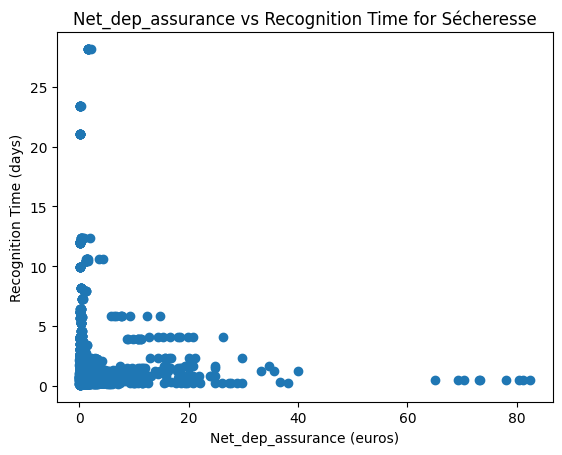

In [25]:
plt.scatter(
    merged_data3["Net_dep_assurance"] / merged_data3["Net_dep_assurance"].mean(),
    merged_data3["recognition_time"] / merged_data3["recognition_time"].mean(),
)
plt.xlabel("Net_dep_assurance (euros)")
plt.ylabel("Recognition Time (days)")
plt.title("Net_dep_assurance vs Recognition Time for Sécheresse")


corr1 = merged_data3[["Net_dep_assurance", "recognition_time"]].corr(method="spearman")
print(corr1)